In [1]:
# All Libraries
import os
import cv2
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt
from pathlib import Path
from PIL import Image

In [2]:
# Taking color dataset
data = '/kaggle/input/plantvillage-dataset/color'

In [3]:
Target_Size = (64, 64)

In [4]:
# checking image and for dubbing
def show_data_pil(path):
    x = []
    y = []
    
    for fol in os.listdir(path):
        print(path)
        label = os.path.join(path, fol)
        print(label)
        for fil in os.listdir(label):
            fig = plt.figure(figsize=(10, 7))
            img_path = os.path.join(label, fil)
            print(img_path)
            img = Image.open(img_path)
            plt.subplot(1, 2, 1)
            plt.imshow(img)
            resized_img = img.resize((64, 64), Image.LANCZOS)
            plt.subplot(1, 2, 2)
            plt.imshow(resized_img)
            img_arr = np.array(resized_img)
            print(img_arr.shape)
            break
        break

/kaggle/input/plantvillage-dataset/color
/kaggle/input/plantvillage-dataset/color/Tomato___Late_blight
/kaggle/input/plantvillage-dataset/color/Tomato___Late_blight/781e93a9-2059-42de-8075-658033a6abf7___RS_Late.B 6075.JPG
(64, 64, 3)


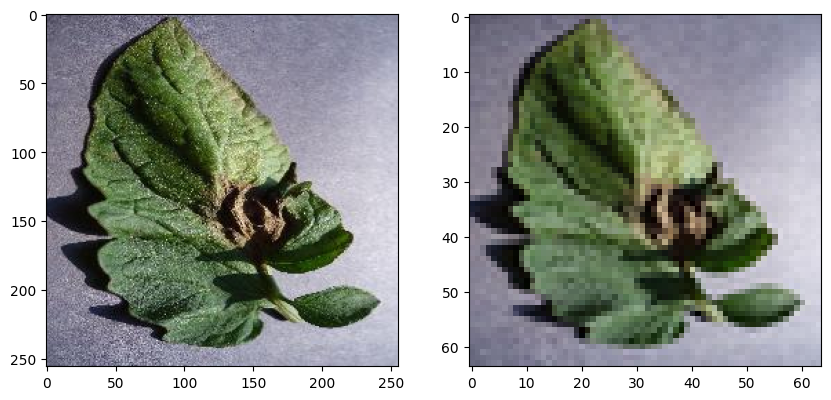

In [5]:
show_data_pil(data)

In [6]:
# Function to load the data and convet to 1d array
def load_data_cv2(path):
    x = []
    y = []

    for fol in os.listdir(path):
        label = os.path.join(path, fol)
        for fil in os.listdir(label):
            img_path = os.path.join(label, fil)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            resized_img = cv2.resize(img, (64, 64), interpolation=cv2.INTER_LANCZOS4)
            flat_img = resized_img.flatten()
            x.append(flat_img)
            y.append(fol)

    return x, y

In [7]:
# Loading data
X, y = load_data_cv2(data)

In [8]:
# Verifying correct loading
print(len(X[0]))
print(len(X))
print(len(y))

12288
54305
54305


In [9]:
# Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
# Dummy Accuracy
dummy_model = DummyClassifier(strategy = "most_frequent")
dummy_model.fit(X_train_scaled, y_train)
dummy_model.score(X_test_scaled, y_test)

0.10579136359451248

In [12]:
# Random forest as basline
randomforest_model = RandomForestClassifier()
randomforest_model.fit(X_train_scaled, y_train)
predict_forest = randomforest_model.predict(X_test_scaled)
print(classification_report(y_test, predict_forest))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.73      0.18      0.30       119
                                 Apple___Black_rot       0.72      0.44      0.55       123
                          Apple___Cedar_apple_rust       1.00      0.02      0.04        48
                                   Apple___healthy       0.60      0.57      0.59       305
                               Blueberry___healthy       0.74      0.83      0.78       324
          Cherry_(including_sour)___Powdery_mildew       0.68      0.46      0.54       213
                 Cherry_(including_sour)___healthy       0.77      0.37      0.50       166
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.33      0.01      0.02       111
                       Corn_(maize)___Common_rust_       0.98      1.00      0.99       240
               Corn_(maize)___Northern_Leaf_Blight       0.56      0.67      0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [13]:
# Confusion matrix
matrix = confusion_matrix(y_test, predict_forest)
matrix

array([[ 22,   1,   0, ...,   7,   0,   3],
       [  0,  54,   0, ...,  14,   0,   1],
       [  0,   0,   1, ...,  16,   0,   3],
       ...,
       [  0,   0,   0, ..., 935,   0,   0],
       [  0,   0,   0, ...,  22,   1,   1],
       [  0,   0,   0, ...,   6,   0, 215]])

In [14]:
matrix.shape

(38, 38)

<Figure size 1600x1200 with 0 Axes>

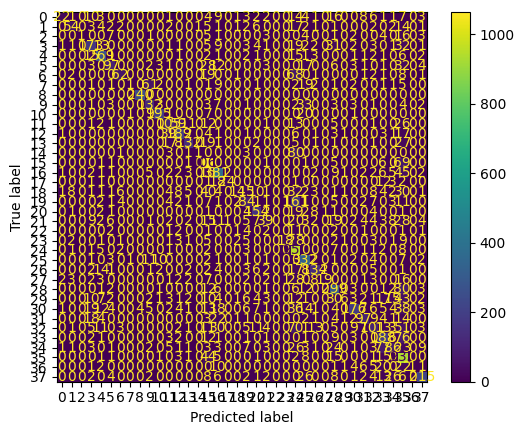

In [15]:
plt.figure(figsize=(16,12))
fig = ConfusionMatrixDisplay(matrix)
fig.plot()
plt.show()